# Replicacion McCloud (2022): Efecto del Inflation Targeting sobre la Inversion Domestica en Mexico
## Pipeline de Datos con Python

**Objetivo:** Construir el panel de datos necesario para replicar el Synthetic Control Method (SCM) de McCloud (2022), enfocado en Mexico como unidad tratada.

**Paper original:** McCloud, N. (2022). "Does domestic investment respond to inflation targeting? A synthetic control investigation." *International Economics*, 169, 98-134.

**Equipo:** Este notebook es autocontenido y ejecutable paso a paso. Al final se indican las tareas que requieren trabajo manual.

---

## 0. Setup del Entorno

Instalar las librerias necesarias (ejecutar solo la primera vez):

In [ ]:
# !pip install pysyncon requests pandas numpy matplotlib -q

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import time
from pysyncon import Dataprep, Synth
from pysyncon.utils import PlaceboTest
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuracion
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

DATA_DIR = Path('../data')
OUT_DIR = Path('../out')
DATA_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

print('Librerias cargadas correctamente.')

Librerias cargadas correctamente.


---
## 1. Descarga de Datos: World Bank API

Usamos directamente la API del Banco Mundial (v2) porque `wbwdi` tiene un bug de schema inference en Polars con descargas grandes. La API es REST, publica, y no requiere autenticacion.

**Endpoint:** `https://api.worldbank.org/v2/country/{paises}/indicator/{codigo}?format=json&per_page=1000`

### Indicadores requeridos por McCloud (2022):

| Variable | Codigo WDI | Descripcion |
|----------|-----------|-------------|
| Gross capital formation (% GDP) | `NE.GDI.TOTL.ZS` | Outcome principal |
| GDP growth (annual %) | `NY.GDP.MKTP.KD.ZG` | Predictor |
| Gross domestic savings (% GDP) | `NY.GNS.ICTR.ZS` | Predictor |
| Population, total | `SP.POP.TOTL` | Predictor (se transforma a log) |
| GDP deflator | `NY.GDP.DEFL.ZS` | Predictor |
| Lending interest rate (%) | `FR.INR.LEND` | Robustness |
| FDI inflows (% GDP) | `BX.KLT.DINV.WD.GD.ZS` | Robustness |
| FDI outflows (% GDP) | `BM.KLT.DINV.WD.GD.ZS` | Robustness |

**Documentacion de la API:** https://datahelpdesk.worldbank.org/knowledgebase/articles/898581-api-basic-call-structure

In [6]:
# Definir los indicadores y el rango de anios
INDICATORS = {
    'NE.GDI.TOTL.ZS':       'gross_capital_formation',
    'NY.GDP.MKTP.KD.ZG':    'gdp_growth',
    'NY.GNS.ICTR.ZS':       'gross_savings',
    'SP.POP.TOTL':          'population',
    'NY.GDP.DEFL.ZS':       'gdp_deflator',
    'FR.INR.LEND':          'lending_rate',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows',
    'BM.KLT.DINV.WD.GD.ZS': 'fdi_outflows',
}

START_YEAR = 1984
END_YEAR = 2023

print(f'Descargando {len(INDICATORS)} indicadores para {START_YEAR}-{END_YEAR}...')
print('Usando API directa del Banco Mundial (wbwdi tiene bug de schema en Polars).')

Descargando 8 indicadores para 1984-2023...
Usando API directa del Banco Mundial (wbwdi tiene bug de schema en Polars).


In [7]:
def fetch_wdi_indicator(indicator_code, indicator_name, start_year, end_year):
    """
    Descarga un indicador del World Bank API v2.
    
    La API devuelve JSON paginado. Cada pagina tiene metadata [0]
    y datos [1]. Iteramos hasta que no haya mas paginas.
    
    Parameters
    ----------
    indicator_code : str
        Codigo WDI (ej. 'NY.GDP.MKTP.KD.ZG')
    indicator_name : str
        Nombre descriptivo para la columna de salida
    start_year, end_year : int
    
    Returns
    -------
    pd.DataFrame con columnas: [country_code, country_name, year, {indicator_name}]
    """
    base_url = "https://api.worldbank.org/v2/country/all/indicator"
    url = f"{base_url}/{indicator_code}"
    
    records = []
    page = 1
    total_pages = None
    
    while True:
        params = {
            'format': 'json',
            'per_page': 1000,
            'page': page,
            'date': f'{start_year}:{end_year}'
        }
        
        try:
            resp = requests.get(url, params=params, timeout=60)
            resp.raise_for_status()
            data = resp.json()
        except Exception as e:
            print(f'  Error en pagina {page}: {e}')
            break
        
        # data[0] = metadata, data[1] = registros
        if total_pages is None:
            total_pages = data[0].get('pages', 1)
        
        if not data or len(data) < 2 or data[1] is None:
            break
        
        for item in data[1]:
            records.append({
                'country_code': item['countryiso3code'],
                'country_name': item['country']['value'],
                'year': int(item['date']),
                indicator_name: item['value']
            })
        
        if page >= total_pages:
            break
        page += 1
    
    return pd.DataFrame(records)


# Descargar todos los indicadores
all_dfs = []
for code, name in INDICATORS.items():
    print(f'  Descargando: {name} ({code})...')
    df_ind = fetch_wdi_indicator(code, name, START_YEAR, END_YEAR)
    print(f'    -> {len(df_ind)} filas')
    all_dfs.append(df_ind)

# Merge secuencial (todos comparten country_code, country_name, year)
print('\nConsolidando indicadores...')
df_raw = all_dfs[0]
for df_ind in all_dfs[1:]:
    df_raw = df_raw.merge(df_ind, on=['country_code', 'country_name', 'year'], how='outer')

# Convertir columnas numericas
for name in INDICATORS.values():
    df_raw[name] = pd.to_numeric(df_raw[name], errors='coerce')

print(f'Dimensiones finales: {df_raw.shape}')
print(f'Columnas: {df_raw.columns.tolist()}')
df_raw.head()

  Descargando: gross_capital_formation (NE.GDI.TOTL.ZS)...
    -> 10640 filas
  Descargando: gdp_growth (NY.GDP.MKTP.KD.ZG)...
    -> 10640 filas
  Descargando: gross_savings (NY.GNS.ICTR.ZS)...
    -> 10640 filas
  Descargando: population (SP.POP.TOTL)...
    -> 10640 filas
  Descargando: gdp_deflator (NY.GDP.DEFL.ZS)...
    -> 10640 filas
  Descargando: lending_rate (FR.INR.LEND)...
    -> 10640 filas
  Descargando: fdi_inflows (BX.KLT.DINV.WD.GD.ZS)...
    -> 10640 filas
  Descargando: fdi_outflows (BM.KLT.DINV.WD.GD.ZS)...
    -> 10640 filas

Consolidando indicadores...
Dimensiones finales: (10640, 11)
Columnas: ['country_code', 'country_name', 'year', 'gross_capital_formation', 'gdp_growth', 'gross_savings', 'population', 'gdp_deflator', 'lending_rate', 'fdi_inflows', 'fdi_outflows']


,country_code,country_name,year,gross_capital_formation,gdp_growth,gross_savings,population,gdp_deflator,lending_rate,fdi_inflows,fdi_outflows
0,,High income,1984,25.392046,4.707562,22.771878,1.135690e+09,NaN,NaN,0.520573,0.553356
1,,High income,1985,24.824391,3.508837,21.927667,1.143179e+09,NaN,NaN,0.327769,0.498372
2,,High income,1986,24.904445,3.192143,21.529238,1.150810e+09,NaN,NaN,0.590282,0.770561
3,,High income,1987,25.169581,3.500853,21.885593,1.158607e+09,NaN,NaN,0.900811,1.038767
4,,High income,1988,26.066570,4.615883,22.825125,1.166528e+09,NaN,NaN,0.921398,1.175132


---
## 2. Exploracion y Limpieza de Datos

In [8]:
# Filtrar solo paises (excluir agregados regionales como 'World', 'Latin America', etc.)
# Los agregados regionales NO tienen codigo ISO de 3 letras (country_code = '' o NaN).
valid_mask = df_raw['country_code'].notna() & (df_raw['country_code'] != '')
df = df_raw[valid_mask].copy()

# Filtrar por rango de anios de trabajo
df = df[(df['year'] >= START_YEAR) & (df['year'] <= END_YEAR)].copy()

print(f'Paises/entidades unicos: {df["country_name"].nunique()}')
print(f'Observaciones despues de filtrar agregados: {df.shape[0]}')
print(f'\nAgregados excluidos (ejemplos):')
agg_examples = df_raw[~valid_mask]['country_name'].unique()[:10]
for ex in agg_examples:
    print(f'  - {ex}')

Paises/entidades unicos: 261
Observaciones despues de filtrar agregados: 10440

Agregados excluidos (ejemplos):
  - High income
  - Low income
  - Lower middle income
  - Not classified
  - Upper middle income


In [9]:
# Crear variables derivadas
df['log_population'] = np.log(df['population'])

# Analizar missing values en variables clave
key_vars = ['gross_capital_formation', 'gdp_growth', 'gross_savings',
            'log_population', 'gdp_deflator']

print('Missing values por variable (total):')
print(df[key_vars].isnull().sum())
print(f'\nMissing como % del total: {(df[key_vars].isnull().sum() / len(df) * 100).round(2)}')

Missing values por variable (total):
gross_capital_formation    2775
gdp_growth                  766
gross_savings              3873
log_population                6
gdp_deflator               2473
dtype: int64

Missing como % del total: gross_capital_formation    26.58
gdp_growth                  7.34
gross_savings              37.10
log_population              0.06
gdp_deflator               23.69
dtype: float64


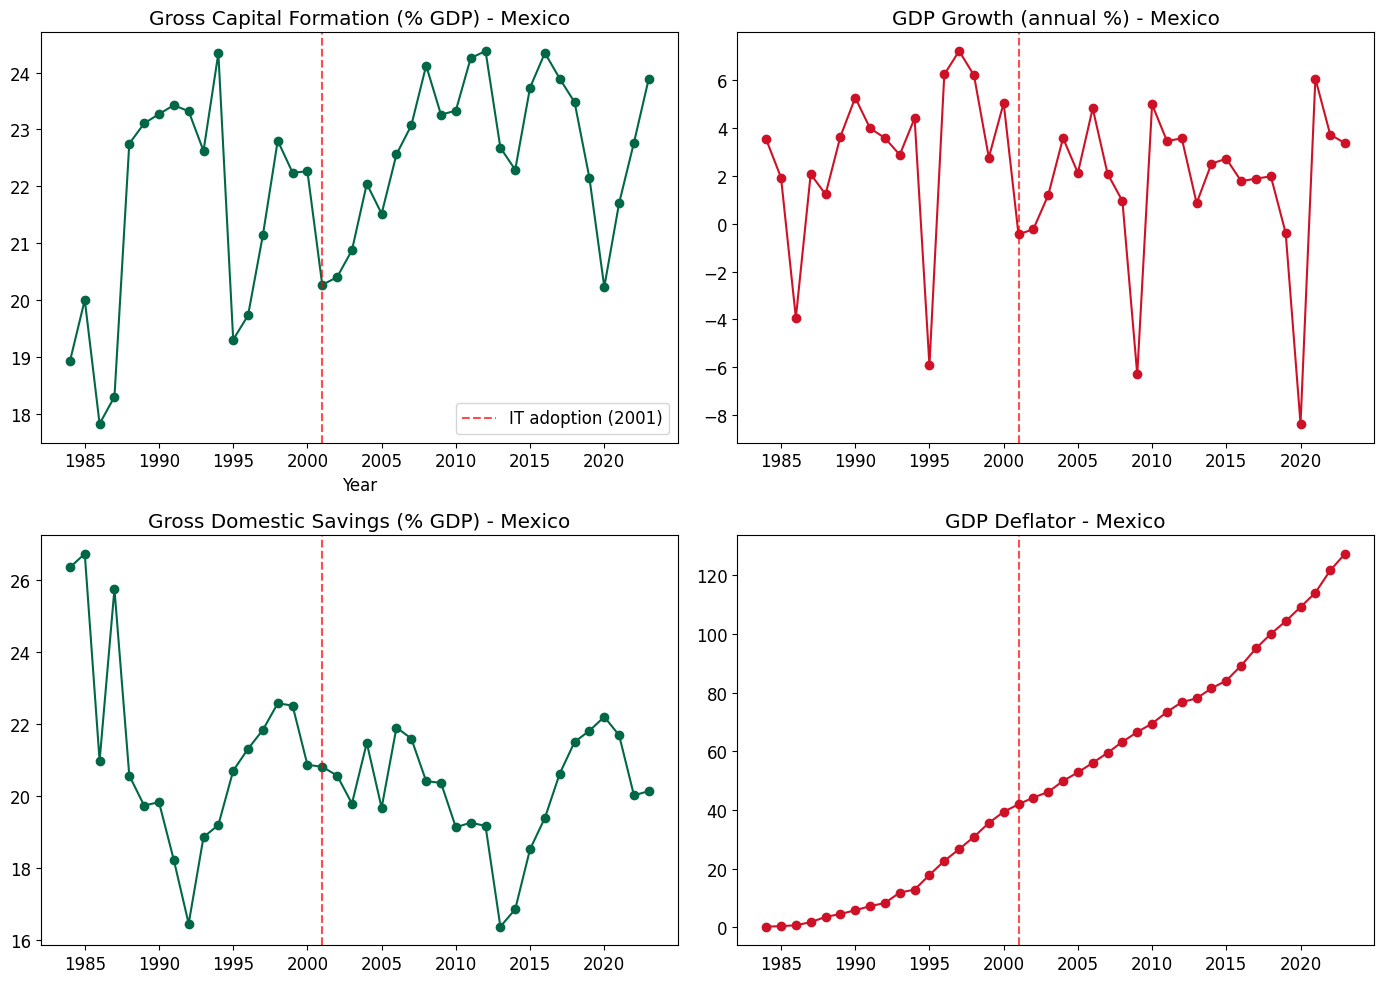

Series historicas de Mexico graficadas. La linea roja marca la adopcion de IT (2001).


In [10]:
# Visualizar cobertura temporal para Mexico
mexico = df[df['country_name'] == 'Mexico'].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(mexico['year'], mexico['gross_capital_formation'], 'o-', color='#006847')
axes[0, 0].axvline(x=2001, color='red', linestyle='--', alpha=0.7, label='IT adoption (2001)')
axes[0, 0].set_title('Gross Capital Formation (% GDP) - Mexico')
axes[0, 0].set_xlabel('Year')
axes[0, 0].legend()

axes[0, 1].plot(mexico['year'], mexico['gdp_growth'], 'o-', color='#ce1126')
axes[0, 1].axvline(x=2001, color='red', linestyle='--', alpha=0.7)
axes[0, 1].set_title('GDP Growth (annual %) - Mexico')

axes[1, 0].plot(mexico['year'], mexico['gross_savings'], 'o-', color='#006847')
axes[1, 0].axvline(x=2001, color='red', linestyle='--', alpha=0.7)
axes[1, 0].set_title('Gross Domestic Savings (% GDP) - Mexico')

axes[1, 1].plot(mexico['year'], mexico['gdp_deflator'], 'o-', color='#ce1126')
axes[1, 1].axvline(x=2001, color='red', linestyle='--', alpha=0.7)
axes[1, 1].set_title('GDP Deflator - Mexico')

plt.tight_layout()
plt.savefig(OUT_DIR / 'mexico_series_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Series historicas de Mexico graficadas. La linea roja marca la adopcion de IT (2001).')

---
## 3. Clasificacion de Paises: Inflation Targeting

**Esta seccion requiere trabajo manual.** La clasificacion de paises que adoptaron Inflation Targeting y sus fechas proviene del IMF Annual Report on Exchange Arrangements and Exchange Restrictions (AREAER), que **no esta disponible via API**. McCloud (2022) usa la edicion 2019.

A continuacion codificamos la lista de los 29 paises IT segun McCloud (2022, Table A.1).

In [11]:
# Clasificacion manual de IT adopters segun IMF AREAER (2019)
# Fuente: McCloud (2022), Table A.1, pp. 125-126
# Formato: {pais: anio_adopcion}

IT_ADOPTERS = {
    # Desarrollados
    'Australia': 1993,
    'Canada': 1991,
    'Finland': 1993,
    'Iceland': 2001,
    'Israel': 1992,
    'Japan': 2013,
    'Korea, Rep.': 2001,
    'New Zealand': 1990,
    'Norway': 2001,
    'Spain': 1995,
    'Sweden': 1995,
    'United Kingdom': 1997,
    # En desarrollo / emergentes
    'Brazil': 1999,
    'Chile': 1991,
    'Colombia': 2000,
    'Czech Republic': 1998,
    'Dominican Republic': 2012,
    'Ghana': 2007,
    'Guatemala': 2005,
    'Hungary': 2001,
    'Indonesia': 2005,
    'Mexico': 2001,
    'Paraguay': 2013,
    'Peru': 2002,
    'Philippines': 2002,
    'Poland': 1999,
    'Romania': 2005,
    'Thailand': 2000,
    'Uruguay': 2007,
}

# NOTA: Verificar que estos nombres coincidan exactamente con los de WDI.
# Puede requerir ajustes (e.g., 'Korea, Rep.' vs 'South Korea').

print(f'Paises IT: {len(IT_ADOPTERS)}')
print(f'Desarrollados: 12 (estimado)')
print(f'En desarrollo / emergentes: 17 (estimado)')
print(f'\nLatinoamericanos IT: {[c for c in IT_ADOPTERS if c in ["Brazil", "Chile", "Colombia", "Dominican Republic", "Guatemala", "Mexico", "Paraguay", "Peru", "Uruguay"]]}')

Paises IT: 29
Desarrollados: 12 (estimado)
En desarrollo / emergentes: 17 (estimado)

Latinoamericanos IT: ['Brazil', 'Chile', 'Colombia', 'Dominican Republic', 'Guatemala', 'Mexico', 'Paraguay', 'Peru', 'Uruguay']


In [12]:
# Agregar columnas de IT al DataFrame
df['is_it'] = df['country_name'].isin(IT_ADOPTERS.keys()).astype(int)
df['it_year'] = df['country_name'].map(IT_ADOPTERS)

# Verificar cuantos paises IT estan en los datos
it_in_data = df[df['is_it'] == 1]['country_name'].unique()
it_missing = [c for c in IT_ADOPTERS if c not in it_in_data]

print(f'Paises IT en los datos WDI: {len(it_in_data)}/{len(IT_ADOPTERS)}')
if it_missing:
    print(f'\nATENCION - Paises IT no encontrados en WDI: {it_missing}')
    print('Revisar los nombres de pais y ajustar el diccionario IT_ADOPTERS.')

Paises IT en los datos WDI: 28/29

ATENCION - Paises IT no encontrados en WDI: ['Czech Republic']
Revisar los nombres de pais y ajustar el diccionario IT_ADOPTERS.


### Dummies adicionales (manuales)

Estas variables tambien deben codificarse manualmente:

In [13]:
# OECD Members (segun OECD 2020)
# Fuente: https://www.oecd.org/en/about/members.html
# NOTA: Verificar membresia historica (algunos paises se unieron despues de 1984)

OECD_MEMBERS = {
    'Australia', 'Austria', 'Belgium', 'Canada', 'Chile', 'Colombia',
    'Costa Rica', 'Czech Republic', 'Denmark', 'Estonia', 'Finland',
    'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland',
    'Israel', 'Italy', 'Japan', 'Korea, Rep.', 'Latvia', 'Lithuania',
    'Luxembourg', 'Mexico', 'Netherlands', 'New Zealand', 'Norway',
    'Poland', 'Portugal', 'Slovak Republic', 'Slovenia', 'Spain',
    'Sweden', 'Switzerland', 'Turkey', 'United Kingdom', 'United States'
}
# NOTA: Varios de estos se unieron a OECD despues de 1984.
# Para una replicacion exacta, codificar la membresia anual.

df['oecd_member'] = df['country_name'].isin(OECD_MEMBERS).astype(int)

In [ ]:
# Oil exporter dummy (>1M barrels/day promedio 1984-2016 segun EIA 2019)
# Usamos la misma API del Banco Mundial para produccion de petroleo.
#   EN.PET.PROD.KT = crude oil production (kt)
#   1 barrel ~ 0.1364 tonnes → 1M barrels/day ~ 365M barrels/year ~ 49.8M tonnes/year
#   Umbral WDI aproximado: ~50,000 kt por anio
#
# NOTA: Para replicacion exacta, codificar segun la lista de McCloud (EIA 2019).
# Esta es una aproximacion automatica con datos WDI.

print('Descargando datos de produccion de petroleo...')
oil_raw = fetch_wdi_indicator('EN.PET.PROD.KT', 'oil_prod_kt', 1984, 2016)

if len(oil_raw) > 0:
    oil_raw['oil_prod_kt'] = pd.to_numeric(oil_raw['oil_prod_kt'], errors='coerce')
    
    # Promedio 1984-2016
    oil_avg = oil_raw.groupby('country_name')['oil_prod_kt'].mean().reset_index()
    # Umbral: ~50,000 kt = 1M barrels/dia aproximado
    oil_avg['oil_exporter'] = (oil_avg['oil_prod_kt'] > 50000).astype(int)
    
    # Merge al panel principal
    df = df.merge(oil_avg[['country_name', 'oil_exporter']], on='country_name', how='left')
    df['oil_exporter'] = df['oil_exporter'].fillna(0).astype(int)
    
    exporters = oil_avg[oil_avg['oil_exporter'] == 1]['country_name'].tolist()
    print(f'Paises clasificados como oil exporters (>1M bbl/d): {len(exporters)}')
    print(f'Top 10 por produccion:')
    top10 = oil_avg.nlargest(10, 'oil_prod_kt')[['country_name', 'oil_prod_kt']]
    for _, row in top10.iterrows():
        print(f'  {row["country_name"]}: {row["oil_prod_kt"]:.0f} kt promedio')
else:
    print('No se pudo descargar datos de petroleo.')
    print('Codificar manualmente con datos de EIA 2019.')
    df['oil_exporter'] = 0

---
## 4. Construccion del Panel Balanceado para SCM

El SCM requiere un panel perfectamente balanceado en el periodo pre-tratamiento. Esto significa:
- Ningun predictor puede tener missing values en 1984-2000.
- El outcome no puede tener missing values en ningun anio.

Exploramos la disponibilidad de datos y seleccionamos la muestra.

In [ ]:
# Definir variables del modelo base
BASE_PREDICTORS = ['gdp_growth', 'gross_savings', 'log_population',
                   'gdp_deflator', 'oil_exporter', 'oecd_member']
OUTCOME = 'gross_capital_formation'
TREATMENT_YEAR = 2001  # Para Mexico
PRE_START = 1984
PRE_END = 2000  # Ultimo anio pre-tratamiento

# Separar periodo pre-tratamiento
pre_mask = (df['year'] >= PRE_START) & (df['year'] <= PRE_END)
df_pre = df[pre_mask].copy()

print(f'Periodo pre-tratamiento: {PRE_START}-{PRE_END}')
print(f'Observaciones pre-tratamiento: {df_pre.shape[0]}')
print(f'Paises en el panel pre-tratamiento: {df_pre["country_name"].nunique()}')

In [ ]:
# Identificar paises con datos completos en predictores durante todo el pre-tratamiento
all_vars = BASE_PREDICTORS + [OUTCOME]

# Para cada pais, contar missing values en el periodo pre
completeness = df_pre.groupby('country_name')[all_vars].apply(
    lambda x: x.isnull().sum().sum()
).reset_index(name='missing_count')

complete_countries = completeness[completeness['missing_count'] == 0]['country_name'].tolist()

print(f'Paises con datos completos en pre-tratamiento: {len(complete_countries)}')

# Verificar que Mexico esta en la lista
if 'Mexico' in complete_countries:
    print('Mexico TIENE datos completos en pre-tratamiento.')
else:
    print('ATENCION: Mexico NO tiene datos completos. Revisar missing values.')

In [ ]:
# Construir la muestra final
# Tratados: paises IT con datos completos
# Control: paises no-IT con datos completos

treated_pool = [c for c in complete_countries if c in IT_ADOPTERS]
donor_pool = [c for c in complete_countries if c not in IT_ADOPTERS]

print(f'Muestra final:')
print(f'  Tratados (IT): {len(treated_pool)} paises')
print(f'  Donantes (no-IT): {len(donor_pool)} paises')
print(f'  Total: {len(treated_pool) + len(donor_pool)} paises')
print(f'\n  McCloud original: 29 IT + 75 control = 104 paises')
print(f'\nTratados incluidos: {treated_pool}')
print(f'\nTratados EXCLUIDOS por missing data: {[c for c in IT_ADOPTERS if c not in treated_pool]}')

In [ ]:
# Guardar el panel limpio
sample_countries = treated_pool + donor_pool
df_final = df[df['country_name'].isin(sample_countries)].copy()

# Asegurar tipos correctos
df_final['year'] = df_final['year'].astype(int)
df_final = df_final.sort_values(['country_name', 'year']).reset_index(drop=True)

output_path = DATA_DIR / 'panel_mccloud_mexico.csv'
df_final.to_csv(output_path, index=False)
print(f'Panel guardado en: {output_path}')
print(f'Dimensiones finales: {df_final.shape}')

---
## 5. Preparacion de la Estructura SCM con pysyncon

Usamos `Dataprep` para estructurar los datos y `Synth` para estimar el control sintetico de Mexico.

In [ ]:
def prepare_predictor_columns(df, outcome, year_range):
    """
    Crea columnas para cada valor anual del outcome en el periodo pre-tratamiento.
    Esto es CRUCIAL para replicar el ajuste casi perfecto de McCloud para Mexico.
    
    McCloud incluye TODOS los valores pre-tratamiento del outcome como predictores
    adicionales, siguiendo a Ferman et al. (2018). Esto fuerza al algoritmo SCM
    a ajustar toda la trayectoria temporal, no solo el promedio.
    """
    outcome_by_year = {}
    for yr in year_range:
        col_name = f'{outcome}_{yr}'
        yr_data = df[df['year'] == yr][['country_name', outcome]].copy()
        yr_data = yr_data.rename(columns={outcome: col_name})
        outcome_by_year[col_name] = yr_data
    return outcome_by_year


def build_panel_for_pysyncon(df, treated_unit, controls, predictors,
                              outcome, time_var, unit_var,
                              pre_start, pre_end, treatment_year):
    """
    Construye el DataFrame en formato requerido por pysyncon Dataprep.
    
    pysyncon espera un panel donde:
    - Cada fila es un anio
    - Cada columna es una variable (predictor u outcome)
    - El unit_variable identifica el pais
    
    Para special_predictors (valores anuales del outcome), necesitamos
    columnas separadas por anio.
    """
    # Crear columnas del outcome por anio para el periodo pre-tratamiento
    pre_years = list(range(pre_start, treatment_year))
    
    # Panel en formato largo -> features para pysyncon
    # pysyncon.Dataprep acepta el panel directamente y aplica operadores
    # sobre time_predictors_prior.
    # 
    # Para los special_predictors (lags del outcome):
    # Cada anio pre-tratamiento del outcome se trata como predictor independiente.
    
    # Primero pivotear el outcome para tener columnas por anio
    outcome_pivot = df.pivot(index=unit_var, columns=time_var,
                              values=outcome)
    outcome_cols = [c for c in outcome_pivot.columns
                    if pre_start <= c < treatment_year]
    outcome_pivot = outcome_pivot[outcome_cols].reset_index()
    outcome_pivot.columns = [unit_var] + [f'{outcome}_{c}' for c in outcome_cols]
    
    return outcome_pivot, pre_years


print('Funciones auxiliares definidas.')

In [ ]:
# Construir el objeto Dataprep para Mexico
# 
# Estrategia: Usamos special_predictors para incluir cada valor anual
# del outcome en el periodo pre-tratamiento (1984-2000).
# Esto es lo que permite el R^2 ~ 1.00 reportado por McCloud.

# Filtrar panel a la muestra de trabajo
work_df = df_final.copy()

# Construir special predictors: un predictor por cada anio pre-tratamiento del outcome
pre_years = list(range(PRE_START, TREATMENT_YEAR))

special_predictors = [
    (OUTCOME, [yr], 'mean') for yr in pre_years
]

print(f'Se incluiran {len(special_predictors)} special predictors')
print(f'(valores anuales de {OUTCOME} para {PRE_START}-{PRE_END})')
print(f'\nPredictores base: {BASE_PREDICTORS}')
print(f'Outcome: {OUTCOME}')
print(f'Unidad tratada: Mexico')
print(f'Periodo tratamiento: {TREATMENT_YEAR}')
print(f'Periodo pre-tratamiento: {PRE_START}-{PRE_END}')

In [ ]:
# Crear Dataprep y ajustar Synth
#
# NOTA: Este bloque puede fallar si hay missing values residuales.
# Si falla, volver a la seccion 4 y ajustar la muestra.

try:
    dataprep = Dataprep(
        foo=work_df,
        predictors=BASE_PREDICTORS,
        special_predictors=special_predictors,
        dependent=OUTCOME,
        unit_variable='country_name',
        time_variable='year',
        treatment_identifier='Mexico',
        controls_identifier=[c for c in donor_pool if c != 'Mexico'],
        time_predictors_prior=range(PRE_START, TREATMENT_YEAR),
        time_optimize_ssr=range(PRE_START, TREATMENT_YEAR),
    )
    
    print('Dataprep creado exitosamente.')
    
    # Ajustar Synthetic Control
    synth = Synth()
    synth.fit(dataprep=dataprep, optim_method='Nelder-Mead')
    
    # Pesos del control sintetico
    weights = synth.weights(round=3, threshold=0.001)
    print(f'\nPaises en el control sintetico de Mexico: {len(weights)}')
    print(weights)
    
    # Resumen de ajuste
    summary = synth.summary()
    print(f'\nResumen de predictores:')
    print(summary.to_string())
    
    # Metricas de ajuste pre-tratamiento
    mspe_val = synth.mspe()
    mae_val = synth.mae()
    print(f'\nMSPE pre-tratamiento: {mspe_val:.4f}')
    print(f'MAE pre-tratamiento:  {mae_val:.4f}')
    print(f'(McCloud reporta RMSPE = 0.11 para Mexico)')
    
except Exception as e:
    print(f'Error en la estimacion SCM: {e}')
    print('\nPosibles causas:')
    print('1. Missing values residuales en el panel')
    print('2. Nombres de pais que no coinciden entre WDI y IT_ADOPTERS')
    print('3. Pais no encontrado en controls_identifier o treatment_identifier')
    print('\nRevisar los mensajes anteriores y ajustar.')

---
## 6. Visualizacion del Control Sintetico

In [ ]:
# Graficar trayectoria de Mexico vs su control sintetico
try:
    fig, ax = synth.path_plot(
        treatment_time=TREATMENT_YEAR,
        plot_args={
            'title': f'Mexico vs Synthetic Mexico: {OUTCOME}',
            'xlabel': 'Year',
            'ylabel': 'Gross Capital Formation (% GDP)'
        }
    )
    plt.axvline(x=TREATMENT_YEAR, color='red', linestyle='--', alpha=0.5, label='IT Adoption (2001)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'mexico_synthetic_control.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'No se pudo generar el grafico: {e}')

In [ ]:
# Graficar gaps (efecto del tratamiento)
try:
    synth.gaps_plot(
        treatment_time=TREATMENT_YEAR,
    )
    plt.axvline(x=TREATMENT_YEAR, color='red', linestyle='--', alpha=0.5)
    plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
    plt.title('Efecto del IT sobre la Inversion en Mexico (Gap)')
    plt.ylabel('Diferencia: Mexico Real - Mexico Sintetico (pp)')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'mexico_treatment_gap.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'No se pudo generar el grafico de gaps: {e}')

---
## 7. Placebos e Inferencia

Ejecutamos placebos in-space: estimar el SCM para cada pais de control como si fuera tratado. Luego comparamos la trayectoria de Mexico contra la distribucion de placebos para obtener pseudo p-values.

In [ ]:
%%time
# Placebo tests (in-space)
# ATENCION: Este bloque es computacionalmente intensivo.
# Para 75 donantes, puede tomar varios minutos.

try:
    placebo = PlaceboTest()
    placebo.fit(
        dataprep=dataprep,
        scm=Synth(),
        max_workers=-1,  # Usar todos los CPUs disponibles
        verbose=True
    )
    
    # Pseudo p-value (Fisher exact test, Firpo & Possebom 2018)
    p_val = placebo.pvalue(treatment_time=TREATMENT_YEAR)
    print(f'\nPseudo p-value (Fisher exact): {p_val:.4f}')
    print(f'(McCloud reporta p-values entre 0.080 y 0.093 para Mexico en anios especificos)')
    
    # Graficar gaps de todos los placebos
    placebo.gaps_plot(
        treatment_time=TREATMENT_YEAR,
        mspe_threshold=5.0  # Excluir placebos con mal ajuste pre-tratamiento
    )
    plt.title('Placebo Tests: Mexico vs Donantes')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'mexico_placebo_tests.png', dpi=150, bbox_inches='tight')
    plt.show()
    
except Exception as e:
    print(f'Error en placebos: {e}')
    print('Si el error es de memoria, reducir el donor pool o usar max_workers=1.')

---
## 8. Robustness: ATT Agregado con Augmented SCM

McCloud usa el *partially-pooled SCM* de Ben-Michael et al. (2021) para estimar el efecto promedio del tratamiento (ATT) a traves de todos los paises IT con adopcion escalonada.

`pysyncon` incluye `AugSynth` que implementa exactamente este metodo. Permite estimar el ATT agregado sin necesidad de codigo adicional.

In [ ]:
from pysyncon import AugSynth

# NOTA: AugSynth requiere una estructura de datos diferente.
# Cada unidad tratada debe tener su propio periodo pre/post definido
# por la fecha de adopcion de IT. Esto se implementa en una segunda fase.

print('Augmented SCM disponible via pysyncon.AugSynth.')
print('Implementacion detallada en la Fase 2 del proyecto.')
print('Ver documentacion: https://sdfordham.github.io/pysyncon/augsynth.html')

---
## 9. Proximos Pasos (Trabajo Manual Requerido)

Las siguientes tareas **no son completamente automatizables** y requieren intervention del equipo:

### 9.1 Verificacion de Nombres de Pais

Los nombres de pais en WDI pueden no coincidir exactamente con los del diccionario `IT_ADOPTERS`. Verificar y corregir:

```python
# Ejecutar para ver discrepancias
wdi_countries = set(df['country_name'].unique())
it_countries = set(IT_ADOPTERS.keys())
print('IT adopters NO encontrados en WDI:', it_countries - wdi_countries)
```

### 9.2 Validacion de la Clasificacion IT

- [ ] Verificar fechas de adopcion contra IMF AREAER (2019) o edicion mas reciente.
- [ ] Considerar clasificaciones alternativas: Rose (2007) fecha conservadora para Mexico = 1999.
- [ ] Documentar cualquier discrepancia y su justificacion.

**Fuente:** IMF Annual Report on Exchange Arrangements and Exchange Restrictions.
Disponible en: https://www.imf.org/en/Publications/Annual-Report-on-Exchange-Arrangements-and-Exchange-Restrictions

### 9.3 Codificacion Manual de Variables Binarias

- [ ] **OECD membership historica:** Verificar membresia anual (algunos paises se unieron post-1984).
  - Fuente: https://www.oecd.org/en/about/members.html
- [ ] **Oil exporter:** Validar contra EIA (2019) o construir con datos WDI de produccion.
  - Fuente: https://www.eia.gov/
- [ ] **Institutional quality (robustness):** Datos de ICRG son de pago. Alternativa: World Governance Indicators (WGI) del Banco Mundial.

### 9.4 Panel Balanceado: Decisiones de Inclusion/Exclusion

- [ ] Definir criterio de exclusion por missing values (McCloud no explicita umbral).
- [ ] Evaluar imputacion multiple vs exclusion de paises con datos incompletos.
- [ ] Documentar la muestra final y compararla con los 104 paises de McCloud.
- [ ] Si el donor pool es significativamente menor a 75, considerar predictores alternativos.

### 9.5 Robustness Checks a Implementar

Siguiendo el checklist de McCloud (2022):

- [ ] **Placebos in-time:** Mover el anio de tratamiento a 1997 (4 anios antes de la adopcion real).
- [ ] **Trimming del donor pool:** Excluir donantes con RMSPE pre > 5x y > 20x el RMSPE de Mexico.
- [ ] **Detrending:** Aplicar SCM sobre datos detrended (remover tendencia lineal por pais).
- [ ] **Covariables adicionales:** Inflacion volatility (varianza del GDP deflator pre-IT), lending rates, FDI.
- [ ] **Clasificacion IT alternativa:** Rose (2007) en vez de IMF (2019).
- [ ] **Particion de muestra:** Restringir donor pool a solo developing o solo non-OECD.
- [ ] **Outcome alternativo 1:** Precios de inversion (Penn World Tables, variable `pl_i`).
- [ ] **Outcome alternativo 2:** Inversion privada (WDI `NE.GDI.FPRV.ZS`) — si los datos lo permiten.
- [ ] **Augmented SCM:** ATT agregado con adopcion escalonada via `AugSynth`.

### 9.6 Descarga de Datos Adicionales

- [ ] **Penn World Tables 10.01 o 11.0:** Bajar de https://www.rug.nl/ggdc/productivity/pwt/
  - Variable clave: `pl_i` (price level of investment)
- [ ] **World Governance Indicators:** Bajar via la misma API del Banco Mundial o manualmente del sitio del WB.
  - Indicadores WGI disponibles via API: consultar https://api.worldbank.org/v2/sources/3
  - Variables: Voice & Accountability, Political Stability, Government Effectiveness, Regulatory Quality, Rule of Law, Control of Corruption.
- [ ] **International Country Risk Guide (ICRG):** Datos de pago. Evaluar si WGI es sustituto aceptable.

### 9.7 Contacto con la Autora

McCloud menciona que los resultados completos y el external appendix estan disponibles bajo solicitud:

> "To conserve on space, we relegate the complete set of SCM results to an external appendix."
> "In light of space considerations, we exclude most results, but we can supply them on request."

- [ ] Contactar a Nadine McCloud (University of the West Indies at Mona) para solicitar:
  - External appendix con resultados completos.
  - Codigo de Stata (si esta disponible).
  - Lista exacta de paises en el donor pool y su clasificacion.

### 9.8 Validacion contra Resultados Originales

Una vez obtenidos los primeros resultados:

- [ ] Comparar la composicion del control sintetico de Mexico (13 paises, pesos reportados en el plan).
- [ ] Verificar RMSPE pre-tratamiento ≈ 0.11.
- [ ] Comparar efectos anuales: 2004 (-3.21), 2005 (-3.54), 2007 (-4.79), 2008 (-7.48), 2011 (-6.25).
- [ ] Si los resultados divergen significativamente, documentar posibles causas (muestra diferente, version de WDI, clasificacion IT).

---
## Referencias del Pipeline

- **pysyncon:** https://sdfordham.github.io/pysyncon/
- **World Bank API:** https://datahelpdesk.worldbank.org/knowledgebase/articles/898581-api-basic-call-structure
- **McCloud (2022):** *International Economics*, 169, 98-134.
- **Plan de trabajo detallado:** `../control/planning/replicacion-mccloud2022-mexico.md`